In [8]:
# -*- 变量筛选训练集/测试集分开与比较 -*-
import pandas as pd
from tableone import TableOne

# --- Configuration ---
INPUT_CSV_FILE = 'inter_eng.csv'
FILTERED_CSV_FILE = 'inter_eng_filtered.csv'
OUTPUT_EXCEL_FILE = 'baseline_characteristics_comparison.xlsx'

# --- Variable Definitions ---
preoperative_vars = [
    'Gender', 'Age', 'Height', 'Weight', 'BMI', 'PreopHospitalDays', 'WeightLoss',
    'PreviousAbdominalSurgery', 'OtherMalignancy', 'Comorbidities', 'Diabetes', 'Hypertension',
    'CerebrovascularDisease', 'HeartDisease', 'Smoking', 'Alcohol', 'NeoadjuvantChemo',
    'ASAGrade', 'GastricColorectal', 'Gastrocolorectal', 'PreopWBC', 'PreopHb',
    'PreopAlb', 'PreopALT', 'PreopBUN', 'PreopCr', 'PreopGlucose'
]
intraoperative_vars = [
    'SurgicalApproach', 'OperationTime', 'GastricResectionSite', 'CombinedOrganResection',
    'DistalGastrectomy', 'ProximalGastrectomy', 'TotalGastrectomy', 'ColorectalResectionSite',
    'Stoma', 'IntraopBloodLoss', 'IntraopTransfusion', 'IntraopFluid', 'IntraopHES',
    'IntraopDextran', 'IntraopGelatin', 'IntraopPlasma', 'IntraopColloid', 'PCAUse',
    'EpiduralAnalgesia', 'IntraopDiuretics', 'IntraopVasoactive', 'CD3', 'T_Stage',
    'N_Stage', 'M_Stage', 'TNM_Stage', 'LymphNodesExamined', 'PositiveLymphNodes'
]
postop_management_vars = [
    'NonOpTransfusion', 'NonOpHES', 'NonOpDextran', 'NonOpGelatin', 'NonOpAlbumin',
    'NonOpPlasma', 'NonOpColloid'
]
utility_and_target_vars = ['Center', 'PostopAKI', 'AKIStage']

all_vars_to_compare = preoperative_vars + intraoperative_vars + postop_management_vars
categorical_vars_in_analysis = [
    'Gender', 'WeightLoss', 'PreviousAbdominalSurgery', 'OtherMalignancy', 'Comorbidities',
    'Diabetes', 'Hypertension', 'CerebrovascularDisease', 'HeartDisease', 'Smoking',
    'Alcohol', 'NeoadjuvantChemo', 'ASAGrade', 'GastricColorectal', 'Gastrocolorectal',
    'SurgicalApproach', 'GastricResectionSite', 'CombinedOrganResection', 'DistalGastrectomy',
    'ProximalGastrectomy', 'TotalGastrectomy', 'ColorectalResectionSite', 'Stoma',
    'IntraopTransfusion', 'PCAUse', 'EpiduralAnalgesia', 'IntraopDiuretics',
    'IntraopVasoactive', 'CD3', 'T_Stage', 'N_Stage', 'M_Stage', 'TNM_Stage',
    'NonOpTransfusion'
]

# --- Main Logic ---
def main():
    try:
        df = pd.read_csv(INPUT_CSV_FILE, encoding='gbk')
    except Exception as e:
        print(f"Error reading the file: {e}")
        return

    df.columns = df.columns.str.strip()

    # =================================================================================
    # NEW STEP: Data Cleaning
    # ---------------------------------------------------------------------------------
    # Identify all columns that should be numeric (continuous)
    continuous_vars = [v for v in all_vars_to_compare if v not in categorical_vars_in_analysis]

    # Loop through the continuous variables and convert them to numeric format.
    # The 'coerce' option will turn any non-numeric text (e.g., '--') into NaN (a missing value).
    print("Cleaning data: Converting continuous variables to numeric format...")
    for col in continuous_vars:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        else:
            print(f"Warning: Column '{col}' not found in the dataset and will be skipped.")
    print("Data cleaning complete.")
    # =================================================================================

    # Check for required columns
    center_col_name = utility_and_target_vars[0]
    if center_col_name not in df.columns:
        print(f"CRITICAL ERROR! The grouping column '{center_col_name}' was not found.")
        print("Actual columns are:", list(df.columns))
        return

    # Filter and save the data
    columns_to_keep = utility_and_target_vars + all_vars_to_compare
    df_filtered = df[list(set(col for col in columns_to_keep if col in df.columns))].copy()
    df_filtered.to_csv(FILTERED_CSV_FILE, index=False, encoding='utf-8-sig')
    print(f"Filtered data saved to '{FILTERED_CSV_FILE}'")

    # Create groups for analysis
    data_for_analysis = df_filtered.copy()
    is_validation = data_for_analysis[center_col_name].isin([1, 2])
    is_training = data_for_analysis[center_col_name].isin([3, 4, 5])
    data_for_analysis['group'] = ''
    data_for_analysis.loc[is_training, 'group'] = 'Training Set (centers 3,4,5)'
    data_for_analysis.loc[is_validation, 'group'] = 'Validation Set (centers 1,2)'
    data_for_analysis = data_for_analysis[data_for_analysis['group'] != ''].copy()
    
    if data_for_analysis.empty:
        print("Error: No data available after filtering for centers 1-5.")
        return

    # Generate and save the Table 1
    print("Generating comparison table...")
    table = TableOne(data_for_analysis, columns=all_vars_to_compare, categorical=categorical_vars_in_analysis, groupby='group', pval=True)
    print(table)
    table.to_excel(OUTPUT_EXCEL_FILE)
    print(f"Success! Comparison table saved to '{OUTPUT_EXCEL_FILE}'.")

if __name__ == '__main__':
    main()

Cleaning data: Converting continuous variables to numeric format...
Data cleaning complete.
Filtered data saved to 'inter_eng_filtered.csv'
Generating comparison table...
                                         Grouped by group                                                                                  
                                                  Missing         Overall Training Set (centers 3,4,5) Validation Set (centers 1,2) P-Value
n                                                                    4014                         2446                         1568        
Gender, n (%)                   0                             1443 (35.9)                   886 (36.2)                   557 (35.5)  <0.001
                                1                             2267 (56.5)                  1265 (51.7)                  1002 (63.9)        
                                2                                 9 (0.2)                      0 (0.0)                      9 (0.

Cleaning data to ensure all columns are numeric...
Found 28 continuous variables to plot.
Preparing data for plotting...
Generating plots for the Training Set...
Generating plots for the Test Set...

Successfully saved the plot to 'outlier_comparison_plot.png'


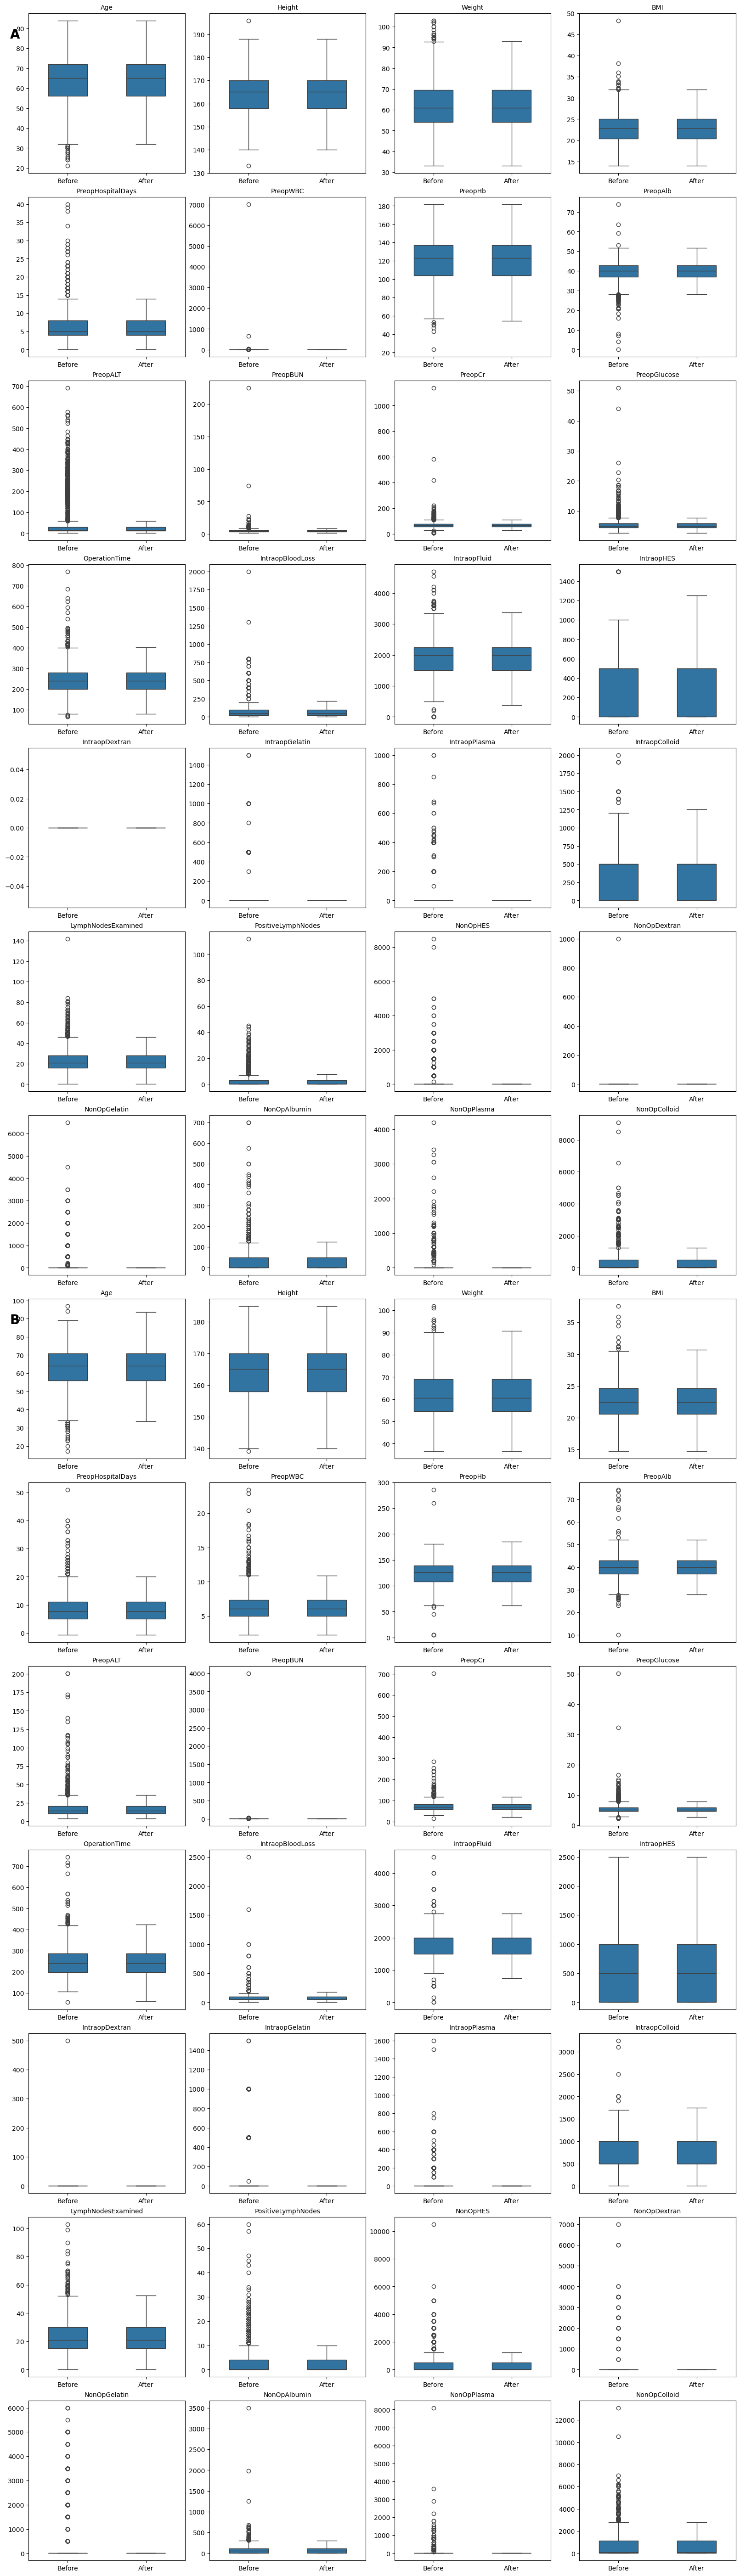

In [17]:
# -*- FigureS1 -*-
"""
This script generates a figure to visualize the effect of outlier processing
on continuous variables for both training and test sets.

The processing method is Winsorization, where outliers are capped at
Q1 - 1.5*IQR and Q3 + 1.5*IQR.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# --- Configuration ---
INPUT_CSV_FILE = 'inter_eng_filtered.csv'
OUTPUT_FIGURE_FILE = 'outlier_comparison_plot.png'

CONTINUOUS_VARS = [
    # 术前指标 (Preoperative)
    'Age', 'Height', 'Weight', 'BMI', 'PreopHospitalDays', 'PreopWBC', 
    'PreopHb', 'PreopAlb', 'PreopALT', 'PreopBUN', 'PreopCr', 'PreopGlucose',
    
    # 术中指标 (Intraoperative)
    'OperationTime', 'IntraopBloodLoss', 'IntraopFluid', 'IntraopHES', 
    'IntraopDextran', 'IntraopGelatin', 'IntraopPlasma', 'IntraopColloid', 
    'LymphNodesExamined', 'PositiveLymphNodes',
    
    # 术后管理指标 (Postoperative Management)
    'NonOpHES', 'NonOpDextran', 'NonOpGelatin', 'NonOpAlbumin', 
    'NonOpPlasma', 'NonOpColloid'
]

# --- Main Logic ---

def winsorize_dataframe(df, var_list):
    df_processed = df.copy()
    for col in var_list:
        if col in df_processed.columns:
            valid_data = df_processed[col].dropna()
            if valid_data.empty:
                continue
            
            Q1 = valid_data.quantile(0.25)
            Q3 = valid_data.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_processed[col] = df_processed[col].clip(lower=lower_bound, upper=upper_bound)
    return df_processed

def create_plot_data(df, var_list):
    df_before = df[var_list].copy()
    df_before_long = df_before.melt(var_name='Variable', value_name='Value')
    df_before_long['Processing'] = 'Before'

    df_after = winsorize_dataframe(df, var_list)
    df_after_long = df_after.melt(var_name='Variable', value_name='Value')
    df_after_long['Processing'] = 'After'
    
    # Combine the two dataframes
    combined_df = pd.concat([df_before_long, df_after_long])
    
    # =================================================================================
    # CRITICAL FIX: Reset the index to resolve the "duplicate labels" error.
    # ---------------------------------------------------------------------------------
    return combined_df.reset_index(drop=True)
    # =================================================================================

def main():
    try:
        df = pd.read_csv(INPUT_CSV_FILE, encoding='utf-8')
    except FileNotFoundError:
        print(f"Error: Could not find the file '{INPUT_CSV_FILE}'.")
        return
    
    print("Cleaning data to ensure all columns are numeric...")
    for col in CONTINUOUS_VARS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    vars_to_plot = [var for var in CONTINUOUS_VARS if var in df.columns]
    if not vars_to_plot:
        print("Error: None of the specified continuous variables were found in the data.")
        return
    else:
        print(f"Found {len(vars_to_plot)} continuous variables to plot.")

    train_df = df[df['Center'].isin([3, 4, 5])].copy()
    test_df = df[df['Center'].isin([1, 2])].copy()

    print("Preparing data for plotting...")
    plot_data_train = create_plot_data(train_df, vars_to_plot)
    plot_data_test = create_plot_data(test_df, vars_to_plot)

    n_vars = len(vars_to_plot)
    n_cols = 4
    n_rows = math.ceil(n_vars / n_cols)
    
    fig, axes = plt.subplots(n_rows * 2, n_cols, figsize=(16, 4 * n_rows * 2), constrained_layout=True)
    
    axes_flat_train = axes[:n_rows, :].flatten()
    axes_flat_test = axes[n_rows:, :].flatten()

    print("Generating plots for the Training Set...")
    for i, var in enumerate(vars_to_plot):
        ax = axes_flat_train[i]
        data_subset = plot_data_train[plot_data_train['Variable'] == var]
        sns.boxplot(data=data_subset, x='Processing', y='Value', ax=ax, width=0.5)
        ax.set_title(var, fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('')

    print("Generating plots for the Test Set...")
    for i, var in enumerate(vars_to_plot):
        ax = axes_flat_test[i]
        data_subset = plot_data_test[plot_data_test['Variable'] == var]
        sns.boxplot(data=data_subset, x='Processing', y='Value', ax=ax, width=0.5)
        ax.set_title(var, fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('')
        
    for i in range(len(vars_to_plot), len(axes_flat_train)):
        axes_flat_train[i].set_visible(False)
        axes_flat_test[i].set_visible(False)
        
    fig.text(0.01, 0.99, 'A', transform=fig.transFigure, fontsize=20, fontweight='bold', va='top')
    fig.text(0.01, 0.49, 'B', transform=fig.transFigure, fontsize=20, fontweight='bold', va='top')
    
    try:
        plt.savefig(OUTPUT_FIGURE_FILE, dpi=300, bbox_inches='tight')
        print(f"\nSuccessfully saved the plot to '{OUTPUT_FIGURE_FILE}'")
    except Exception as e:
        print(f"\nError saving the plot: {e}")

if __name__ == '__main__':
    main()

Successfully loaded 'inter_eng.csv'.
Data split into training and test sets.
Generating plot for the Training Set...
Generating plot for the Test Set...

Successfully saved the plot to 'missing_values_overview.png'


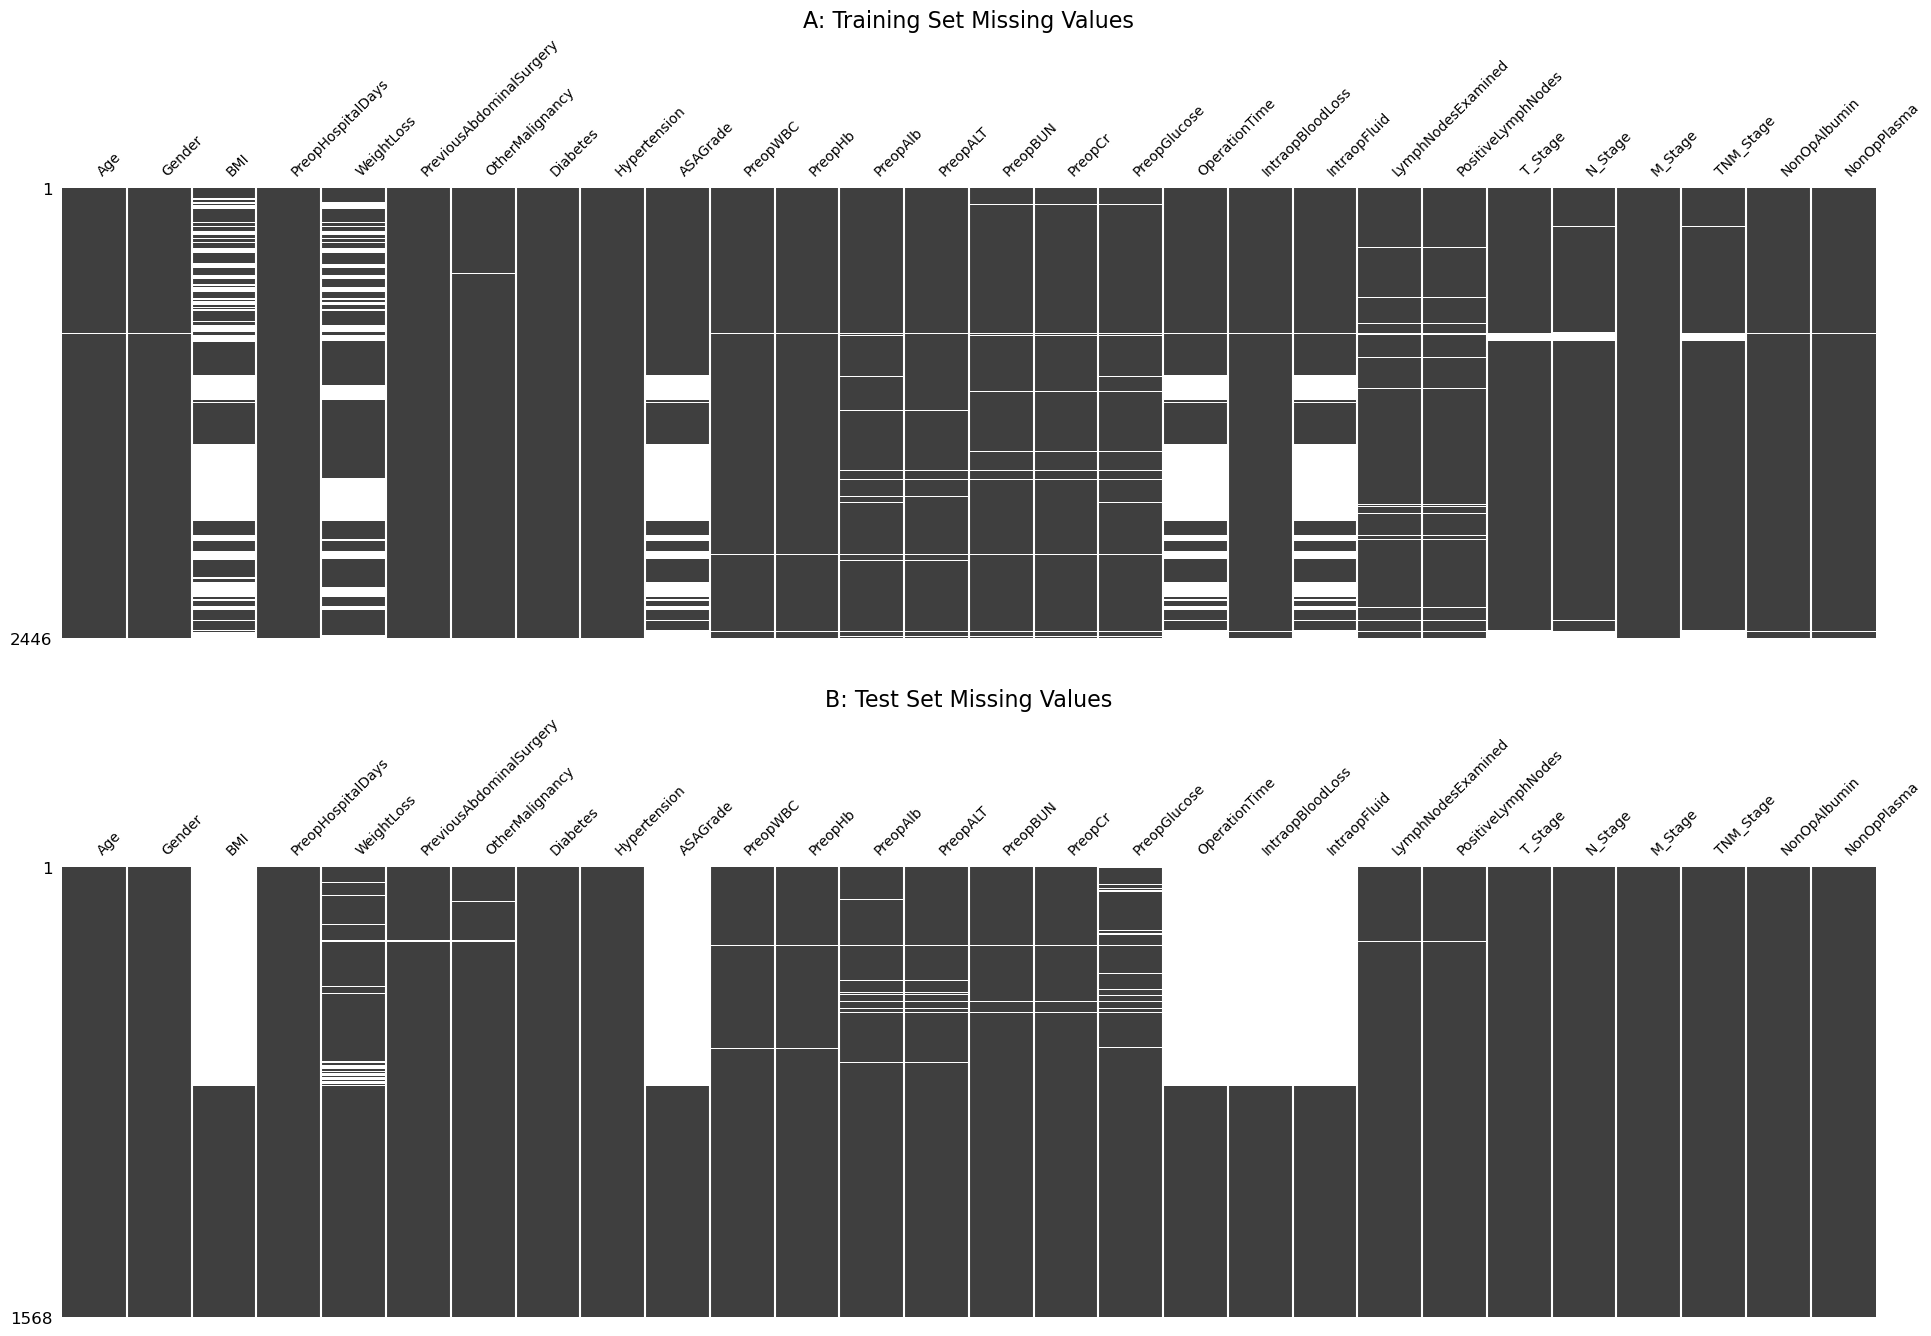

In [18]:
# -*- FigureS2 -*-
"""
This script generates a figure showing the missing value patterns for the
training and test sets, similar to the provided example Figure S2.
"""

import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# --- Configuration ---
INPUT_CSV_FILE = 'inter_eng.csv'
OUTPUT_FIGURE_FILE = 'missing_values_overview.png'

# =================================================================================
# IMPORTANT: This list determines which variables are plotted.
# The example figure shows a selection of variables. I have included a
# comprehensive list from your project below.
# You can add, remove, or reorder variables in this list as you see fit.
# =================================================================================
VARS_TO_PLOT = [
    # Demographics & Preoperative
    'Age', 'Gender', 'BMI', 'PreopHospitalDays', 'WeightLoss', 
    'PreviousAbdominalSurgery', 'OtherMalignancy', 'Diabetes', 'Hypertension', 
    'ASAGrade', 'PreopWBC', 'PreopHb', 'PreopAlb', 'PreopALT', 'PreopBUN', 
    'PreopCr', 'PreopGlucose',
    
    # Intraoperative
    'OperationTime', 'IntraopBloodLoss', 'IntraopFluid', 'LymphNodesExamined', 
    'PositiveLymphNodes',
    
    # Staging
    'T_Stage', 'N_Stage', 'M_Stage', 'TNM_Stage',

    # Postoperative
    'NonOpAlbumin', 'NonOpPlasma'
]

# --- Main Logic ---

def main():
    # 1. Load data
    try:
        df = pd.read_csv(INPUT_CSV_FILE, encoding='gbk')
        print(f"Successfully loaded '{INPUT_CSV_FILE}'.")
    except FileNotFoundError:
        print(f"Error: Could not find the file '{INPUT_CSV_FILE}'.")
        return
        
    # Ensure the columns to plot actually exist in the DataFrame
    vars_in_data = [var for var in VARS_TO_PLOT if var in df.columns]
    if not vars_in_data:
        print("Error: None of the variables in VARS_TO_PLOT were found in the data.")
        return

    # 2. Split data into training and test sets
    train_df = df[df['Center'].isin([3, 4, 5])].copy()
    test_df = df[df['Center'].isin([1, 2])].copy()
    print("Data split into training and test sets.")

    # 3. Set up the figure with two subplots (one for train, one for test)
    # The figsize is (width, height) in inches. We make it tall to accommodate both plots.
    fig, axes = plt.subplots(2, 1, figsize=(20, 14))
    
    # --- Generate Plot A (Training Set) ---
    print("Generating plot for the Training Set...")
    
    # Use the msno.matrix function on the first subplot (axes[0])
    # sparkline=False removes the line on the right to match your example
    msno.matrix(train_df[vars_in_data], ax=axes[0], sparkline=False, fontsize=10)
    
    # Set a title for the subplot
    axes[0].set_title('A: Training Set Missing Values', fontsize=16)
    
    # --- Generate Plot B (Test Set) ---
    print("Generating plot for the Test Set...")

    # Use the msno.matrix function on the second subplot (axes[1])
    msno.matrix(test_df[vars_in_data], ax=axes[1], sparkline=False, fontsize=10)
    
    # Set a title for the subplot
    axes[1].set_title('B: Test Set Missing Values', fontsize=16)

    # Improve layout to prevent titles/labels from overlapping
    plt.tight_layout(pad=3.0)

    # 4. Save the final figure
    try:
        plt.savefig(OUTPUT_FIGURE_FILE, dpi=300, bbox_inches='tight')
        print(f"\nSuccessfully saved the plot to '{OUTPUT_FIGURE_FILE}'")
    except Exception as e:
        print(f"\nError saving the plot: {e}")

if __name__ == '__main__':
    main()

In [1]:
# -*- 缺失值插补 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, brier_score_loss,
                             precision_score, recall_score, f1_score, confusion_matrix)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore', category=UserWarning)

# --- Configuration ---
OUTPUT_FOLDER = 'imputation'
DATA_OUTPUT_FOLDER = os.path.join(OUTPUT_FOLDER, 'imputed_data')
INPUT_CSV_FILE = 'inter_eng.csv'
OUTPUT_EXCEL_FILE = os.path.join(OUTPUT_FOLDER, 'imputation_sensitivity_analysis_results.xlsx')
TARGET_VARIABLE = 'PostopAKI'

# --- Variable Definitions ---
all_predictors_base = [
    'Age', 'Gender', 'BMI', 'PreopHospitalDays', 'WeightLoss', 'PreviousAbdominalSurgery', 
    'OtherMalignancy', 'Diabetes', 'Hypertension', 'CerebrovascularDisease', 
    'HeartDisease', 'Smoking', 'Alcohol', 'NeoadjuvantChemo', 'ASAGrade', 
    'GastricColorectal', 'PreopWBC', 'PreopHb', 'PreopAlb', 'PreopALT', 'PreopBUN', 'PreopCr', 
    'PreopGlucose', 'SurgicalApproach', 'OperationTime', 'CombinedOrganResection', 
    'Stoma', 'IntraopBloodLoss', 'IntraopTransfusion', 'IntraopFluid', 'PCAUse', 
    'EpiduralAnalgesia', 'IntraopDiuretics', 'IntraopVasoactive', 'TNM_Stage', 
    'LymphNodesExamined', 'PositiveLymphNodes'
]
categorical_vars_base = [
    'Gender', 'WeightLoss', 'PreviousAbdominalSurgery', 'OtherMalignancy', 'Diabetes', 
    'Hypertension', 'CerebrovascularDisease', 'HeartDisease', 'Smoking', 'Alcohol', 
    'NeoadjuvantChemo', 'ASAGrade', 'GastricColorectal', 'SurgicalApproach', 
    'CombinedOrganResection', 'Stoma', 'IntraopTransfusion', 'PCAUse', 
    'EpiduralAnalgesia', 'IntraopDiuretics', 'IntraopVasoactive', 'TNM_Stage'
]

# --- Helper Functions ---
def calculate_all_metrics(model, X, y_true):
    y_pred = model.predict(X)
    try:
        y_prob = model.predict_proba(X)[:, 1]
    except AttributeError: # For models like SVM without probability enabled by default, though configured here
        y_prob = y_pred 
        
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    except ValueError:
        tn, fp, fn, tp = 0, 0, 0, 0
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred), 'AUC': roc_auc_score(y_true, y_prob),
        'Brier': brier_score_loss(y_true, y_prob), 'Sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0, 
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0, 
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }
    return metrics

# --- Main Logic ---
def main():
    if not os.path.exists(OUTPUT_FOLDER): os.makedirs(OUTPUT_FOLDER)
    if not os.path.exists(DATA_OUTPUT_FOLDER): os.makedirs(DATA_OUTPUT_FOLDER)
    
    # 1. Load Data
    try:
        df = pd.read_csv(INPUT_CSV_FILE, encoding='gbk')
    except UnicodeDecodeError:
        df = pd.read_csv(INPUT_CSV_FILE, encoding='utf-8')

    print("\n--- Applying Robust Data Cleaning ---")
    continuous_vars_from_base = [v for v in all_predictors_base if v not in categorical_vars_base and v in df.columns]
    for col in continuous_vars_from_base:
        df[col] = df[col].astype(str).str.extract(r'^(\d+[,.]?\d*)', expand=False)
        df[col] = df[col].str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')
    print("Robust data cleaning complete.\n")
    
    # 2. Preprocessing
    df.dropna(subset=[TARGET_VARIABLE], inplace=True)
    df[TARGET_VARIABLE] = df[TARGET_VARIABLE].astype(int)
    
    # Split based on Center
    train_df = df[df['Center'].isin([3, 4, 5])].copy()
    test_df = df[df['Center'].isin([1, 2])].copy()
    
    all_predictors = [v for v in all_predictors_base if v in df.columns and v != TARGET_VARIABLE]
    
    # Define y (Target)
    y_train = train_df[TARGET_VARIABLE]
    y_test = test_df[TARGET_VARIABLE]
    
    # Define X (Features)
    X_train_raw = train_df[all_predictors]
    X_test_raw = test_df[all_predictors]
    
    # One-Hot Encoding
    categorical_vars = [v for v in categorical_vars_base if v in X_train_raw.columns]
    train_index = X_train_raw.index
    test_index = X_test_raw.index
    
    combined_X = pd.concat([X_train_raw, X_test_raw], axis=0)
    combined_X_dummies = pd.get_dummies(combined_X, columns=categorical_vars, drop_first=True)
    
    X_train_raw = combined_X_dummies.loc[train_index]
    X_test_raw = combined_X_dummies.loc[test_index]
    
    # 3. Imputation Methods
    imputers = {
        'mean_mode': SimpleImputer(strategy='most_frequent'), 
        'kNN': KNNImputer(n_neighbors=5),
        'CART': IterativeImputer(estimator=DecisionTreeRegressor(), max_iter=5, random_state=42),
        'random_forest': IterativeImputer(estimator=RandomForestRegressor(n_estimators=10), max_iter=5, random_state=42),
        'bayes_logreg_polyreg': IterativeImputer(estimator=BayesianRidge(), max_iter=5, random_state=42),
        'pmm_logreg_polyreg': IterativeImputer(estimator=BayesianRidge(), sample_posterior=True, max_iter=5, random_state=42)
    }
    
    # 4. Models for Sensitivity Analysis
    models = {
        'LR': LogisticRegression(max_iter=1000, random_state=42), 'DT': DecisionTreeClassifier(random_state=42),
        'RF': RandomForestClassifier(random_state=42), 'KNN': KNeighborsClassifier(),
        'SVM': SVC(probability=True, random_state=42), 'NB': GaussianNB(),
        'XGB': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'SGBT': GradientBoostingClassifier(random_state=42), 'NNET': MLPClassifier(max_iter=1000, random_state=42)
    }
    
    results = []
    
    # 5. Loop through Imputers
    for imp_name, imputer in imputers.items():
        print(f"--- Processing Imputation Method: {imp_name} ---")
        
        # Fit on Train, Transform Train and Test
        imputer.fit(X_train_raw)
        X_train_imputed_unscaled = imputer.transform(X_train_raw)
        X_test_imputed_unscaled = imputer.transform(X_test_raw)
        
        # Create DataFrames
        X_train_imputed_df = pd.DataFrame(X_train_imputed_unscaled, index=X_train_raw.index, columns=X_train_raw.columns)
        X_test_imputed_df = pd.DataFrame(X_test_imputed_unscaled, index=X_test_raw.index, columns=X_test_raw.columns)
        
        # --- 【关键修改】将目标变量 PostopAKI 拼回数据框 ---
        print(f"  Appending target variable '{TARGET_VARIABLE}' back to imputed datasets...")
        X_train_imputed_df[TARGET_VARIABLE] = y_train
        X_test_imputed_df[TARGET_VARIABLE] = y_test
        # ----------------------------------------------------

        # Save to CSV
        X_train_imputed_df.to_csv(os.path.join(DATA_OUTPUT_FOLDER, f'train_imputed_{imp_name}.csv'))
        X_test_imputed_df.to_csv(os.path.join(DATA_OUTPUT_FOLDER, f'test_imputed_{imp_name}.csv'))
        print(f"  Saved imputed data for '{imp_name}' method.")
        
        # --- Prepare for Model Training (Use Features Only) ---
        # Note: We need to drop TARGET_VARIABLE again for scaling and training, 
        # or just use the unscaled numpy arrays we had before appending.
        # Using numpy arrays (X_train_imputed_unscaled) is safer/faster here.
        
        scaler = StandardScaler()
        X_train_imputed = scaler.fit_transform(X_train_imputed_unscaled)
        X_test_imputed = scaler.transform(X_test_imputed_unscaled)
        
        for model_name, model in models.items():
            # print(f"  Training Model: {model_name}") # Optional: reduce clutter
            model.fit(X_train_imputed, y_train)
            
            train_metrics = calculate_all_metrics(model, X_train_imputed, y_train)
            train_metrics.update({'Model': model_name, 'Interpolation Method': imp_name, 'Set': 'Training'})
            results.append(train_metrics)
            
            test_metrics = calculate_all_metrics(model, X_test_imputed, y_test)
            test_metrics.update({'Model': model_name, 'Interpolation Method': imp_name, 'Set': 'Test'})
            results.append(test_metrics)
            
    # 6. Save Sensitivity Analysis Results
    results_df = pd.DataFrame(results)
    with pd.ExcelWriter(OUTPUT_EXCEL_FILE) as writer:
        results_df[results_df['Set'] == 'Training'].to_excel(writer, sheet_name='Training Set Results', index=False)
        results_df[results_df['Set'] == 'Test'].to_excel(writer, sheet_name='Test Set Results', index=False)
    print(f"\nResults table saved to '{OUTPUT_EXCEL_FILE}'")

    # 7. Plotting
    print("\nGenerating separate performance plots...")
    
    results_melted = results_df.melt(
        id_vars=['Model', 'Interpolation Method', 'Set'],
        value_vars=['Accuracy', 'AUC', 'Brier', 'Sensitivity', 'Specificity', 'Precision', 'NPV', 'F1'],
        var_name='Metric', value_name='Value'
    )
    
    metrics_to_plot = results_melted['Metric'].unique()
    sets_to_plot = results_melted['Set'].unique()

    for metric in metrics_to_plot:
        for data_set in sets_to_plot:
            plt.figure(figsize=(14, 7))
            plot_data = results_melted[(results_melted['Metric'] == metric) & (results_melted['Set'] == data_set)]
            
            if plot_data.empty: continue

            ax = sns.barplot(data=plot_data, x='Model', y='Value', hue='Interpolation Method')
            
            ax.set_title(f'{data_set} Set Performance - {metric}', fontsize=18)
            ax.set_xlabel('Model', fontsize=12)
            ax.set_ylabel('Value', fontsize=12)
            ax.tick_params(axis='x', rotation=45, labelsize=10)
            ax.grid(axis='y', linestyle='--', alpha=0.7)
            plt.legend(title='Interpolation Method', bbox_to_anchor=(1.05, 1), loc='upper left')
            
            plot_filename = os.path.join(OUTPUT_FOLDER, f'plot_{data_set}_Set_{metric}.png')
            plt.tight_layout()
            plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
            plt.close()
            
    print("All plots generated.")

if __name__ == '__main__':
    main()


--- Applying Robust Data Cleaning ---
Robust data cleaning complete.

--- Processing Imputation Method: mean_mode ---
  Appending target variable 'PostopAKI' back to imputed datasets...
  Saved imputed data for 'mean_mode' method.
--- Processing Imputation Method: kNN ---
  Appending target variable 'PostopAKI' back to imputed datasets...
  Saved imputed data for 'kNN' method.
--- Processing Imputation Method: CART ---
  Appending target variable 'PostopAKI' back to imputed datasets...
  Saved imputed data for 'CART' method.
--- Processing Imputation Method: random_forest ---
  Appending target variable 'PostopAKI' back to imputed datasets...
  Saved imputed data for 'random_forest' method.
--- Processing Imputation Method: bayes_logreg_polyreg ---
  Appending target variable 'PostopAKI' back to imputed datasets...
  Saved imputed data for 'bayes_logreg_polyreg' method.
--- Processing Imputation Method: pmm_logreg_polyreg ---
  Appending target variable 'PostopAKI' back to imputed dat

In [5]:
import pandas as pd
import os

# --- 配置 ---
OUTPUT_FOLDER = 'imputation'
OUTPUT_EXCEL_FILE = os.path.join(OUTPUT_FOLDER, 'imputation_sensitivity_analysis_results.xlsx')

def evaluate_imputation_comprehensive():
    if not os.path.exists(OUTPUT_EXCEL_FILE):
        print(f"错误：找不到结果文件 {OUTPUT_EXCEL_FILE}。")
        return

    print("-" * 80)
    print("插补方法综合评估报告 (训练集 vs 测试集)")
    print("-" * 80)

    try:
        # 1. 读取两个 Sheet
        df_test = pd.read_excel(OUTPUT_EXCEL_FILE, sheet_name='Test Set Results')
        df_train = pd.read_excel(OUTPUT_EXCEL_FILE, sheet_name='Training Set Results')
    except ValueError as e:
        print(f"错误：读取 Excel Sheet 失败。请检查文件内容。\n{e}")
        return

    # 2. 定义聚合函数
    agg_func = {'AUC': 'mean', 'F1': 'mean', 'Sensitivity': 'mean'}

    # 3. 分别计算 Test 和 Train 的均值
    summary_test = df_test.groupby('Interpolation Method').agg(agg_func)
    summary_train = df_train.groupby('Interpolation Method').agg(agg_func)

    # 4. 重命名列以区分
    summary_test.columns = [f'Test_{col}' for col in summary_test.columns]
    summary_train.columns = [f'Train_{col}' for col in summary_train.columns]

    # 5. 合并数据
    summary_final = pd.concat([summary_test, summary_train], axis=1)

    # 6. 计算关键指标：泛化差距 (Overfitting Gap)
    # Gap 越小越好（前提是 Test AUC 高）
    summary_final['AUC_Gap'] = summary_final['Train_AUC'] - summary_final['Test_AUC']

    # 7. 排序：优先按 Test_AUC 降序排列
    summary_final = summary_final.sort_values(by='Test_AUC', ascending=False)

    # 8. 格式化输出
    # 只保留关键列，让显示更清晰
    cols_to_show = ['Test_AUC', 'Train_AUC', 'AUC_Gap', 'Test_Sensitivity', 'Test_F1']
    print("\n🏆 各插补方法综合排名 (按测试集 AUC 降序):")
    print("注意观察 AUC_Gap: 值过大(>0.05)可能意味着过拟合")
    print("-" * 80)
    print(summary_final[cols_to_show].round(4))

    # 9. 智能推荐
    best_method = summary_final.index[0]
    best_test_auc = summary_final.iloc[0]['Test_AUC']
    best_gap = summary_final.iloc[0]['AUC_Gap']

    print("-" * 80)
    print(f"✅ 推荐的最佳插补方法: 【 {best_method} 】")
    print(f"   - 测试集平均 AUC: {best_test_auc:.4f}")
    print(f"   - 训练集平均 AUC: {summary_final.iloc[0]['Train_AUC']:.4f}")
    print(f"   - 泛化差距 (Gap): {best_gap:.4f} ", end="")
    
    if best_gap > 0.1:
        print("(⚠️ 警告：差距较大，存在过拟合风险)")
    elif best_gap < -0.02:
        print("(⚠️ 注意：测试集表现优于训练集，可能是数据分布差异导致)")
    else:
        print("(✅ 表现稳健)")

    # 10. (可选) 查看最佳方法在不同模型下的稳定性
    print("-" * 80)
    print(f"该方法 ({best_method}) 在各下游模型上的【测试集】表现:")
    model_details = df_test[df_test['Interpolation Method'] == best_method][['Model', 'AUC', 'Sensitivity']]
    print(model_details.sort_values(by='AUC', ascending=False).round(4))

if __name__ == '__main__':
    evaluate_imputation_comprehensive()

--------------------------------------------------------------------------------
插补方法综合评估报告 (训练集 vs 测试集)
--------------------------------------------------------------------------------

🏆 各插补方法综合排名 (按测试集 AUC 降序):
注意观察 AUC_Gap: 值过大(>0.05)可能意味着过拟合
--------------------------------------------------------------------------------
                      Test_AUC  Train_AUC  AUC_Gap  Test_Sensitivity  Test_F1
Interpolation Method                                                         
random_forest           0.6434     0.9337   0.2903            0.1260   0.0659
CART                    0.6400     0.9335   0.2935            0.1274   0.0648
bayes_logreg_polyreg    0.6396     0.9329   0.2933            0.1301   0.0705
kNN                     0.6360     0.9334   0.2973            0.1233   0.0575
mean_mode               0.6359     0.9333   0.2974            0.1260   0.0675
pmm_logreg_polyreg      0.6288     0.9341   0.3053            0.1301   0.0696
------------------------------------------------